# Klasyfikacja

Jest typ zadania **uczenia nadzorowanego** w którym zmienna przewidywana jest typu kategorycznego, czyli posiada **okreśłoną ilość wartości**. Jest ona zwana **Label** (etykieta) lub potocznie labelką. W zależności od ilości labelek wyróżnia się jeszcze następujące typy klasyfikacji:


*   Binarna (Binary Classification) - 2 etykiety, zazwyczaj Tak/Nie, chory/zdrowy, spam/nie spam
*   Wieloklasowa (Multiclass Classification) -  ilość etykiet >= 3, np. pies / kot / szop
* Multilabel Classification (Wieloetykietowa?) - To samo co wieloklasowa. lecz jednej obserwacji może być przydizlone wiele etykiet, np wszystkie obiekty znalezione/rozpoznane na obrazku.



In [214]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff


## Regresja Logistyczna

Zaczniemy od dość sporej modyfikacji poznanej na poprzedniej lekcji regresjii Liniowej, czyli **Regresji Logistycznej** (Logistic regression).

Celem regresji ligistycznej nie jest przewidywanie wartości współczynnikór linii (czyli dopasowanie linii do danych) lecz przewidzenie na ile % dana obserwacja należdy do danej klasy np. klasy kot. A więc model przewiduje:

<div align="center">
$P(y='kot'|x) = \sigma(w \cdot x + b)$
</div>
gdzie:


*   $x$ - wektor cech (kolumn)
*   $w$ - wagi poszczególnych cech
*   $b$ - bias
*   $σ$ - Funkcja Sigmoid

Algorytm ten wykorzystuje funkcję sigmoid która mapuje dowolną liczbe rzeczyiwstą do przedziału $(0, 1)$, czyli pozwala nam zamienić naszą predykcje na %.
Wzór funkcji Sigmoid:

<div align="center">

$\sigma(z) = \frac{1}{1 + e^{-z}}
$

</div>


Natomiast funkcją optymalizowaną przez nasz model podczas treningu jest **Log-Likelihood** dane wzorem:

<div align="center">
$L = \prod_{i=1}^n P(y_i|x_i)$
</div>
Czyli jest to nasza funkcja kosztu.

Algorytm ten trenowany jest za pomocą algorytmu **Gradient Descent**, ale o tym za niedługo. W skórcie stopniowo minimalizujemy wartośc naszej funkcji kosztu na podstawie predykcji naszego modelu.

</div>


In [215]:
X, y = make_classification(
    n_samples = 1000,
    n_features = 1,
    n_informative = 1,
    n_redundant = 0,
    n_classes = 2,
    n_clusters_per_class = 1,
    random_state = 42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_range_prob = model.predict_proba(X_range)[:, 1]


fig = make_subplots(rows = 1, cols = 2, subplot_titles=["Funkcja Sigmoid", "Log-Odds"])


fig.add_trace(
    go.Scatter(
        x = X_range.flatten(),
        y = y_range_prob,
        mode = 'lines',
        line = dict(color='red', width=2),
        name = 'Funkcja Sigmoid'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x = X.flatten(),
        y = y,
        mode = 'markers',
        marker = dict(color=['red' if label == 1 else 'blue' for label in y], size=10, line=dict(color='black', width=1)),
        name = 'Obserwacje na sigmoidzie'
    ),
    row = 1, col = 1
)

fig.add_trace(
    go.Scatter(
        x = X_range.flatten(),
        y = [0.5] * len(X_range),
        mode = 'lines',
        line = dict(color='gray', dash='dash'),
        name = 'Granica decyzyjna (0.5)'
    ),
    row = 1, col = 1
)

log_odds = model.intercept_ + model.coef_ * X_range
log_odds_points = model.intercept_ + model.coef_ * X

fig.add_trace(
    go.Scatter(
        x = X_range.flatten(),
        y = log_odds.flatten(),
        mode = 'lines',
        line = dict(color = 'blue', width = 2),
        name = 'Log-Odds (Z)'
    ),
    row = 1, col = 2
)

fig.add_trace(
    go.Scatter(
        x = X.flatten(),
        y = log_odds_points.flatten(),
        mode = 'markers',
        marker = dict(color=['red' if label == 1 else 'blue' for label in y], size=10, line=dict(color='black', width=1)),
        name = 'Obserwacje na log-odds'
    ),
    row = 1, col = 2
)


fig.update_layout(
    title_text = 'Wizualizacja Funkcjii Sigmoid i Log-Odds',
    showlegend = False,
    width = 800,
    height = 600
)

fig.update_xaxes(title_text = "Wartość cechy", row = 1, col = 1)
fig.update_yaxes(title_text = "Prawdopodobieństwo klasy 1", row = 1, col = 1)

fig.update_xaxes(title_text = "Wartość cechy", row = 1, col = 2)
fig.update_yaxes(title_text = "Log-Odds (Z)", row = 1, col = 2)

fig.show()



## Ocena modeli klasyfikacji

Zanim przejdziemy do następnych należy wspomnieć o tym jak oceniamy modele klasyfikacji, ponieważ metryk jest parę. Ale zacznijmy od wytłumaczenia czy jest/są:


*   True Positive TP - model poprawnie przewiduje pozytywną klasę, np. diagnozuje chorego pacjenta jako chorego. Czyli dla 1 daje 1
*   True Negative, TN - model poprawnie przewiduje negatywną klasę, np. diagnozuje zdrowego pacjenta jako zdrowego. Czyli dla 0 daje 0
*   False Positive FP - model źle przewiduje pozytywną klasę, np. diagnozuje zdrowego pacjenta jako chorego. Czyli dla 0 daje 1.
*   False Negative, FN - model źle przewiduje negatywną klasę, np. diagnozuje chorego pacjenta jako zdrowego. Czyli dla 1 daje 0.

Możemy przejść teraz do metryk którymi są:


1.   Accuracy, Dokładność - Wskazuje % poprawnych predykcji ze **wszystkich** predykcji. Bardzo ważnym jej aspektem jest to że jest podatna na niezbalansowane zbiory danych. W skrócie przewidywanie najpopularniejszej klasy zawsze da wysoką dokładność, np. jeśli mamy zbiór z 80 pozytywami i 20 negatywami, model który po prostu przewiduje wszystko jako pozytywne będzie miał dokładność rzędu 80%. Dana jest wzorem:

<div align="center">
$
\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
$
</div>

2.   Precision, Precyzja - % pozytywnie przewidzianych wartości które rzeczywiście są pozytywne. Skupiamy się na niej jeśli zależy nam na **redukcji FP**, czyli kiedy 'koszt' pomyłki typu FP jest wysoki. Czyli jeśli model przewidzi 0 FP to będzie miał precyzję na poziomie 1.0 czy 100%. Nie uwzględnia FN. Dana jest wzorem:

<div align="center">
$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$
</div>

3.   Recall, Czułość - Zwany również True Positive Rate (TPR), czyli % rzeczywistych pozytywów przewidzianych jako pozytywne. Skupia się na elyminacji FN, więc jest dla nas ważna gdy 'chybienie' pozytywnego przypadku jest kosztowne, jak np. predykcja choroby. Nie uwzględnia FP. Czyli jeśli model przewidzi 0 FN to będzie miał recall na poziomie 100%. Dany jest wzorem:

<div align="center">
$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$
</div>

4.   F1-Score, wynik F1 - Srednia harmoniczna precyzji i zwrotu. Łączy w sobie istotność obydwóch tych metryk, i jest 'go to' metryką dla niezbalansowanych zbiorów danych. W skócie gdy precyzja i recall mają zbilożne wartości F1 będzie miał wartość zbliżoną do nich. Jeśli się różnią, F1 będzie bardziej zbliżóny do gorszej metryki. Dany jest wzorem:

<div align="center">
$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$
</div>

In [216]:
X, y = make_classification(
    n_samples = 1000,
    n_features = 1,
    n_informative = 1,
    n_redundant = 0,
    n_classes = 2,
    n_clusters_per_class = 1,
    random_state = 42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Dokładność: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Dokładność: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       105
           1       0.91      0.91      0.91        95

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



# Wykresy
Istnieje też parę wykresów, za pomocą których można pokazać wydajność naszego modelu. Pierwszym z nich jest

## 1. **Macierz Pomyłek** (Confusion Matrix).
Jest to najprostsza w świecie graficzna reprezentacja TP, TN, FP, FN. Zależy nam żeby najwięcej obserwacji było na przekątnej, bo to na niej są TP i TN.

In [217]:
cm = confusion_matrix(y_test, y_pred)

fig = ff.create_annotated_heatmap(
    z = cm,
    x = ['Przewidywane 1', 'Przewidywane 0'],
    y = ['Prawdziwe 1', 'Prawdziwe 0'],
    colorscale = 'Blues',
)

fig.update_layout(
    title = 'Macierz Pomyłek',
    xaxis_title = 'Wartości Przewidywane',
    yaxis_title = 'Wartości Prawdziwe',
    width = 600,
    height = 600,
    yaxis=dict(autorange = "reversed") # domyślnie heatmapa w plotly wyświetla macierz w odbiciu lustrzanym, więc ją musimy odwrócić
)



## 2. Krzywa ROC (ROC Curve, ROC = receiver operating characteristic)

Tworzy wykres na podstawie TPR (Recall) oraz FPR(Specificity), czyli odestek rzeczywistych negatywów błędie zaklasyfikowanych jako pozytywy, najprościej mówiąc 'fałszywe alarmy' dany wzorem:

$\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$

 na teoretycznie wszystkich (a praktycznie na wybranych interwałach) wartościach progowych (thresholds). Czyli teoretyczny idealny model , w każdym punkcie wykresu będzie miał TPR rzędu 1.0 a FPR 0.0

Obszar znajdujący się pod wykresem jest zwany **AUC** czyli area under curve. Wskazuje ona na ile % model, któremy dany losowy pozytywny i negatywny przykład, zwróci wyższy wynik dla przykładu pozytywnego. Czyli jeśli mamy AUC rzędu 0.93 oznacza to że istnieje 93% prawdopodobieństwo że model po dostaniu w losowych przykładów, jednego pozytywnego, drugiego negatywnego poprawnie oceni przykład pozytywny wyżej niż negatywny.


In [218]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig = go.Figure()
fig.add_trace(go.Scatter(x = fpr,
                         y = tpr,
                         mode = 'lines',
                         name = f'Krzywa ROC (AUC = {roc_auc:.2f})'))
fig.add_trace(go.Scatter(x = [0, 1],
                         y = [0, 1],
                         mode = 'lines',
                         line = dict(dash = 'dash'),
                         name = 'Losowy model'))
fig.update_layout(
    title = 'Krzywa ROC',
    xaxis_title = 'FPR',
    yaxis_title = 'TPR',
    width = 900,
    height = 500
)
fig.show()



# 3. Krzywa Precision-Recall (Precision-Recall Curve)

Tworzy one wykres porównujący Precyzję (X) i Zwroty (Y) modelu. Stromy spadek krzywej oznacza silny model, czyli ma wysoką precyzję i wysoki zwrot.



In [219]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig = go.Figure()
fig.add_trace(go.Scatter(x = recall,
                         y = precision,
                         mode = 'lines',
                         name = 'Krzywa Precision-Recall'))
fig.update_layout(
    title = 'Krzywa Precision-Recall',
    xaxis_title = 'Zwrot',
    yaxis_title = 'Precyzja',
    width = 800,
    height = 600
)
fig.show()





# Drzewo Decyzyjne

Skoro znamy już parę sposobów oceny naszych modeli, poznajmy jeszcze 1 lub dwa popularne modele.
Pierwszym z nich będzie drzewo decyzyjne, czyli jeden z najbardziej intuicyjnych modelu uczenia maszynowego.

Model ten przyjmuje formę drzewa, praktycznie identycznego w budowę do tego które poznaliśmy na AiSD (Alogsy). Jednak gdy mówimy o klasyfikatorze to co reprezentują jego poszczególne części troszkę się różni, a więc:


*   Wierzchołki (Nodes) - Reprezentują atrybut, a tak naprawdę jego kolejne wartości na podstawie których dzielimy nasze dane. Prawe dziecko zawsze reprezentuje prawdę, lewe fałsz.
*   Liście (Leaf nodes) - Reprezentują finalną predykcję, czyli wynik podziału

W wielkim skrócie drzewo decyzyjne rekursywnie dzieląc nasz zbiór danych na podstawie wartości danych cech, czyli tworząc 'zasady decyzyjne'? (Decision rules). Im głębsze drzewo, tym dokładniejsze zasady, a biorąc pod uwagę że może ono być dowolnej głębokości, klasyfikator ten **radzi sobie z danymi które nie są separowalne (linearly separable)**

A troszkę bardziej szczegółowo:

Celem algorytmu jest znalezienie zasad najlepiej dzielących nasz zbiór danych do wierzchołków **czystych** (**pure nodes**). Im czystszy wierzchołek tym lepiej. Czystość oznacza proporcje jednej klasy do drugiej. Czysty wierzchołek będzie miał w sobie tylko obserwacje należące do 1 klasy, i taki właśnie wierzchołek jest Liściem, czyli decyzją algorytmu.

Czyli czysty wierzchołek będzie miał 10 obserwacji należących do 1 klasy, nieczysty będzie miał np. 6 należących do klasy 1 a 4 do klasy 2.





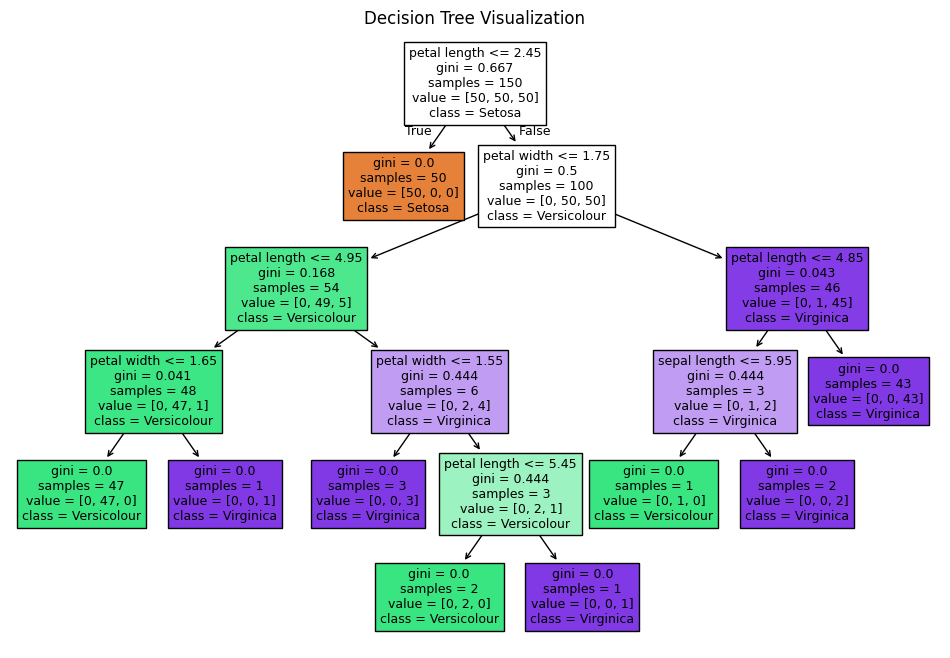

In [220]:
X, y = load_iris(return_X_y = True) # wykorzystamy przykładowy zbiór danych iris

tree = DecisionTreeClassifier(criterion = 'gini',
                              max_depth = 8,
                              random_state = 42)
tree.fit(X, y)

plt.figure(figsize = (12, 8))
plot_tree(tree,
          feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width'],
          class_names = ['Setosa', 'Versicolour', 'Virginica'],
          filled = True)
plt.title('Decision Tree Visualization')
plt.show()

In [221]:
tree = DecisionTreeClassifier(criterion = 'gini',
                              max_depth = 10,
                              random_state = 42)
X_selected_features = X[:, [2, 3]]
tree.fit(X_selected_features, y)

x_min, x_max = X_selected_features[:, 0].min() - 1, X_selected_features[:, 0].max() + 1
y_min, y_max = X_selected_features[:, 1].min() - 1, X_selected_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]) # c_ łączy 2 tablice 1d w 2d, ravel wypłaszcza tablice
Z = Z.reshape(xx.shape)

plt.figure(figsize = (12, 8))

contour = go.Contour(
    x = np.arange(x_min, x_max, 0.01),
    y = np.arange(y_min, y_max, 0.01),
    z = Z,
    opacity = 0.3,
    showscale = False
)

class_traces = []
for class_index, class_name in enumerate(load_iris().target_names):
  class_mask = y == class_index # maskujemy punkty nie należące do danej klasy
  class_traces.append(
      go.Scatter(
          x = X_selected_features[class_mask, 0],
          y = X_selected_features[class_mask, 1],
          mode = 'markers',
          name = class_name,
          marker = dict(
              color = class_index,
              colorscale = 'Viridis',
              line = dict(color='black', width=1)
          ),
          hovertext = [f'Klasa: {class_name}'] * sum(class_mask),
          hoverinfo = 'text',
      )
  )


fig = go.Figure(data = [contour] + class_traces)
fig.update_layout(
    title = 'Granice Decyzyjne',
    xaxis_title = 'Petal Width',
    yaxis_title = 'Petal Length',
    width = 800,
    height = 600
)
fig.show()

<Figure size 1200x800 with 0 Axes>

Jako że drzewa dezyzyjne wybierają najlepsze 'zasady', czyli wartości graniczne w naszych cechach, to można na podstawie tego zidentyfikować najważniejsze cechy w naszym datasecie.

<Axes: >

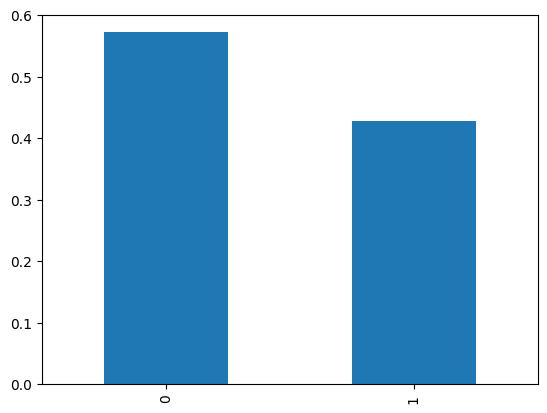

In [222]:
import pandas as pd
pd.Series(tree.feature_importances_).plot.bar()



# Lasy losowe

Jak sama nazwa wskazuje Las losowo to swojego rodzaju zbiór drzew decyzyjnych. Jest jednak w tym pewien haczyk, mianowicie o ile las losowy może korzystać z pełnoprawnych drzew decyzyjnych zazwyczaj skorzysta z tak zwanych 'korzonków decyzyjnych' (decision stumps) czyli drzew o znacznie mniejszej głębokości niż normalne drzewo, np. 1 lub 2 zamiast 7 lub 8 poziomów.

Jest to przykład praktyki zwanej **Ensamble learning** w którym wiele trenowane jest wiele słabszych modeli zwanych 'weak learners' lub 'base models' czesto nie wiele lepszych od rzutu moneta (w przypadku klasyfikacji  binarnej). Sam las losowy jest przykladem **baggingu**, czyli praktyki w której tworzone jest wiele słabych modeli i każdy z nich trenowany jest na podzbiorze oryginalnego zbioru danych utworzonym za pomocą **bootstrap**-ingu, czyli próbkowania naszego zbioru danych **ze zwracaniem**. Wyniki tych modeli sa następnie łączone, czy to za pomocą uśredniania ich wyników dla regresji czy głosowania większościowego dla klasyfikacji a 'model zbiorowy' często ma lepsza skutecznosc niz pojedynczy sylny model.

Wracając do lasu losowego, kolejnymi jego krokami jest:


1.   Utworzenie $N$ zbiorów bootstrapowych z początkowego datasetu
2.   Wytrenowanie drzewa decyzyjnego, korzonka na każdym z tych podzbiorów, wybierając losowe cechy(ich losowy podzbiór) przy każdym podziale
3. W przypadku klasyfikacji finalna predykcja to głosowanie większościowe wszystkich naszych modeli, dla regresji średnia

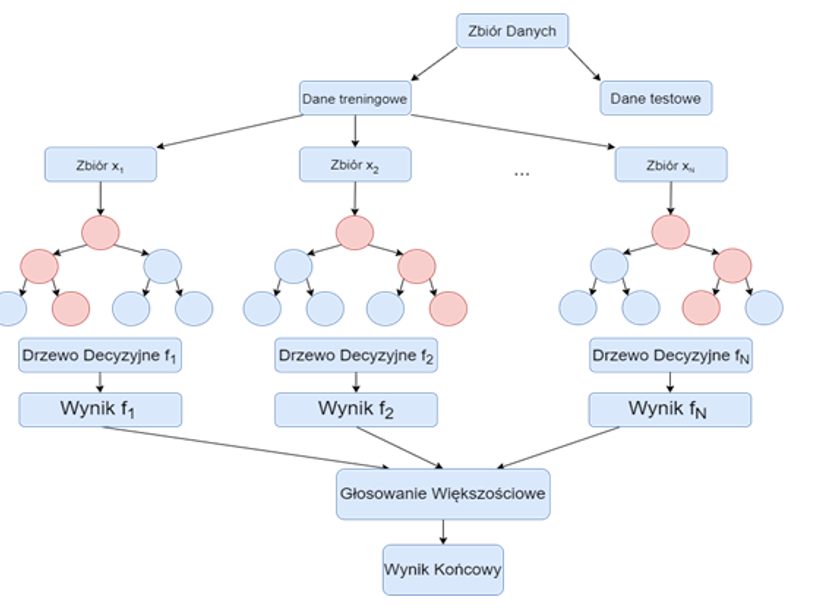





In [223]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100,
                            max_depth = 5,
                            random_state = 42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.925
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       105
           1       0.93      0.91      0.92        95

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.92       200



In [224]:
iris = load_iris()

rf = RandomForestClassifier(n_estimators=200,
                            max_depth = 8,
                            random_state=42)
rf.fit(X_selected_features, y)

x_min, x_max = X_selected_features[:, 0].min() - 1, X_selected_features[:, 0].max() + 1
y_min, y_max = X_selected_features[:, 1].min() - 1, X_selected_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = rf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


contour = go.Contour(
    x = np.arange(x_min, x_max, 0.01),
    y = np.arange(y_min, y_max, 0.01),
    z = Z,
    opacity = 0.3,
    showscale = False
)


class_traces = []
for class_index, class_name in enumerate(load_iris().target_names):
    class_mask = y == class_index
    class_traces.append(
        go.Scatter(
            x = X_selected_features[class_mask, 0],
            y = X_selected_features[class_mask, 1],
            mode = 'markers',
            name = class_name,
            marker = dict(
                color = class_index,
                colorscale = 'Viridis',
                line = dict(color = 'black', width = 1)
            ),
            hovertext=[f'Klasa: {class_name}'] * sum(class_mask),
            hoverinfo='text',
        )
    )

fig = go.Figure(data=[contour] + class_traces)
fig.update_layout(
    title = 'Granice Decyzyjne (Random Forest)',
    xaxis_title = 'Petal Width',
    yaxis_title = 'Petal Length',
    width = 800,
    height = 600
)


fig.show()


# SVM, Support Vector Machines, Maszyny Wektrów Nośnych

W tym przypadku celem modelu jest wyznaczenie hiperpłaszczyzny dzielącej nasz zbiór daych na poszczególen klasy, z jak najmniejszym marginesem błędu. W tym celu wykorzystujemy **Support Vectors** (wektory nośne)

In [225]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_selected_features, y)

x_min, x_max = X_selected_features[:, 0].min() - 1, X_selected_features[:, 0].max() + 1
y_min, y_max = X_selected_features[:, 1].min() - 1, X_selected_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

contour = go.Contour(
    x = np.arange(x_min, x_max, 0.01),
    y = np.arange(y_min, y_max, 0.01),
    z = Z,
    opacity = 0.3,
    showscale = False
)

class_traces = []
for class_index, class_name in enumerate(load_iris().target_names):
    class_mask = y == class_index
    class_traces.append(
        go.Scatter(
            x = X_selected_features[class_mask, 0],
            y = X_selected_features[class_mask, 1],
            mode = 'markers',
            name = class_name,
            marker = dict(
                color=class_index,
                colorscale = 'Viridis',
                line = dict(color='black', width=1)
            ),
            hovertext = [f'Klasa: {class_name}'] * sum(class_mask),
            hoverinfo = 'text',
        )
    )

support_vector_trace = go.Scatter(
    x = svm.support_vectors_[:, 0],
    y = svm.support_vectors_[:, 1],
    mode = 'markers',
    name = 'Wektory nośne / wsparcia',
    marker = dict(
        color = 'black',
        size = 12,
        symbol = 'x',
        line = dict(color = 'white', width = 1)
    ),
    hoverinfo = 'skip'
)

fig = go.Figure(data=[contour] + class_traces + [support_vector_trace])
fig.update_layout(
    title = 'Granice Decyzyjne (SVM)',
    xaxis_title = 'Petal Width',
    yaxis_title = 'Petal Length',
    width = 800,
    height = 600
)

fig.show()


Jeśli chodzi o ensemble learning to mamy jeszcze pare typow, a konkretniej:

## 1. Boosting
czyli podobnie jak w przypadku baggingu, trenowane jest wiele słabszych modeli, lecz tym razem nie są one od siebie niezależne. każdy następny model ma za zadanie 'naprawiać błędy' poprzedniego.

Konkretniej, każdy kolejny słaby model (bardzo czesto drzewo decyzyjne) uczy sie przewidywac rezydua (błędy) poprzedniego, obserwacja źle klasyfikowanym nadawane są większe wagi (problematyczne/trudne przypadki), a poprawnie klasyfikowanym mniejsze (łatwe przypadki). Finalna predykcja to podobnie jak w przypadku bagging głosowanie większościowe lub średnia, w przypadku regresji.

Popularnymi algorytmami/modelami boosting jest np. AdaBoost, Gradient Boosting i XGBoosting, czyli extreme gradient boosting.

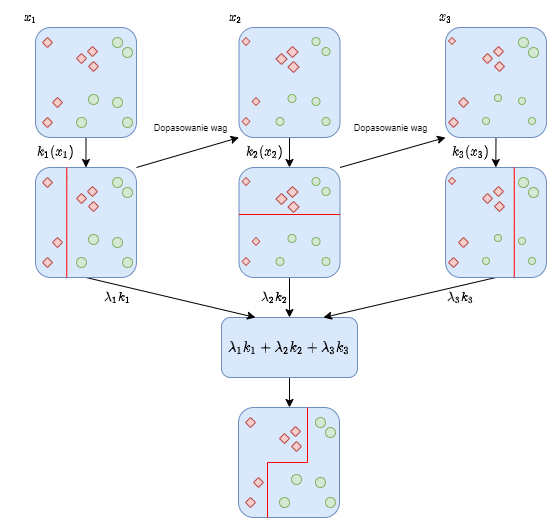

In [226]:
from xgboost import XGBClassifier

X, y = load_iris(return_X_y = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(
    n_estimators = 100,       # liczba bazowych modeli, w tym przypadku drzew decyzyjnych
    learning_rate = 0.1,      # tępo nauki, więcej o tym pogadamy przy ANN
    max_depth = 3,            # maksymalna głębokość drzewa
    random_state = 42,
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



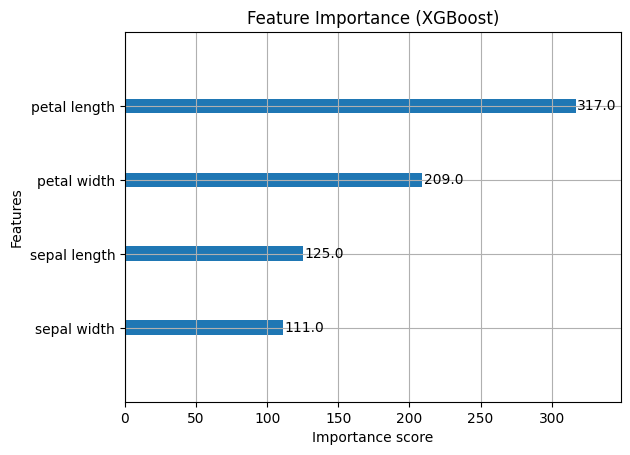

In [227]:
from xgboost import plot_importance
xgb_model.get_booster().feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']
plot_importance(xgb_model, importance_type='weight')
plt.title("Feature Importance (XGBoost)")
plt.show()



## 2. Stacking
 lub Stacked Generalization wykorzystuje kilka podstawowych modeli, zwanych modelami poziomu 0 (**Level 0 Models**), jak poprzednio będą dopasowywały się do naszych danych. Oprócz nich będzie równierz tworzony **Meta-Model** lub model poziomu 1 (**Level 1 model**). Jest on trenowany na produkcjach modeli bazowych, wraz z prawdziwymi etykietami tworząc w ten sposób jego zbiór treningowy.




In [228]:
from mlxtend.classifier import StackingClassifier

X, y = make_classification(
    n_samples = 10000,
    n_features = 10,
    n_informative = 10,
    n_redundant = 0,
    n_classes = 4,
    n_clusters_per_class = 1,
    random_state = 42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestClassifier(n_estimators = 100,
                                  random_state = 42)

model_tree = DecisionTreeClassifier(criterion = 'gini',
                                    max_depth = 3,
                                    random_state = 42)

meta_model = LogisticRegression()

stack = StackingClassifier(
    classifiers = [model_rf, model_tree],
    meta_classifier = meta_model,
    use_probas = True,  # meta model będzie używał prawdopodobieństw, a nie etykiet
    verbose = 1
)

stack.fit(X_train, y_train)

y_pred = stack.predict(X_test)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 2 classifiers...
Fitting classifier1: randomforestclassifier (1/2)
Fitting classifier2: decisiontreeclassifier (2/2)
Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       518
           1       0.95      0.94      0.94       495
           2       0.92      0.91      0.92       485
           3       0.89      0.91      0.90       502

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000

